# Updated-plate partial-Cholesky projection enclosure (v7)

This notebook implements the stated partial-Cholesky algorithm for `system_updated_plate` at intervals of 1,000, always including `m=n`. The same reverse-Cuthill–McKee ordering and Jacobi scaling used by `system_updated_plate_to_completion.ipynb` are applied first. Thus every `A[:m, :m]` below is literally a leading principal block of the established permuted, scaled computational system; shrinkage results are restored to original physical-coordinate order before saving.

Every block is independently converted from sparse storage to lower-banded storage and passed to `scipy.linalg.cholesky_banded`. No full factor is truncated, no projector is formed, and each block factor is reused with `cho_solve_banded`. Only the actually nonzero columns of `A12` are materialized.

The supplied primary box is `box_1`. Its containment check is performed and reported before the sweep. The same endpoint-wise effective-box correction as the completion notebook is retained as an explicit branch, but it is used only if the original supplied box fails containment. Shrinkage widths are evaluated after unscaling to the original physical coordinates.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

from pathlib import Path
import gc
import time

from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from scipy.linalg import cholesky_banded, cho_solve_banded
from scipy.sparse import diags, load_npz
from scipy.sparse.csgraph import reverse_cuthill_mckee

data_dir = Path("system_updated_plate")
results_dir = Path("system_updated_plate_solver_v7_results")
results_dir.mkdir(exist_ok=True)


## Load, scale, reorder, and audit `box_1`

With `D = sqrt(diag(A))`, the scaled variables satisfy `y = D x`, `A_hat = D^{-1} A D^{-1}`, and `b_hat = D^{-1} b`. Reverse Cuthill–McKee is then applied exactly as in the completion notebook to control banded fill. The full-size factor computed here is the requested `m=n` factor and is reused at the end of the sweep.

In [2]:
A_physical = load_npz(data_dir / "A.npz").tocsr()
b_physical = np.loadtxt(data_dir / "b.dat", dtype=float)
stored_solution = np.loadtxt(data_dir / "soln_x.dat", dtype=float)
supplied_box = np.loadtxt(data_dir / "box_1.dat", dtype=float)

n = b_physical.size
if A_physical.shape != (n, n) or supplied_box.shape != (n, 2):
    raise ValueError("Updated-plate matrix, right-hand side, or box has an unexpected shape.")
if np.any(supplied_box[:, 0] > supplied_box[:, 1]):
    raise ValueError("box_1 contains inverted intervals.")

diagonal = A_physical.diagonal()
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat_native = (diags(inverse_scale) @ A_physical @ diags(inverse_scale)).tocsr()
b_hat_native = inverse_scale * b_physical

permutation = reverse_cuthill_mckee(A_hat_native, symmetric_mode=True)
A_hat = A_hat_native[permutation][:, permutation].tocsr()
b_hat = b_hat_native[permutation]
scale_permuted = scale[permutation]
inverse_scale_permuted = inverse_scale[permutation]

native_rows, native_columns = A_hat_native.nonzero()
native_bandwidth = int(np.max(np.abs(native_rows - native_columns)))
rows, columns = A_hat.nonzero()
permuted_bandwidth = int(np.max(np.abs(rows - columns)))
del native_rows, native_columns, rows, columns

def leading_principal_banded(m):
    """Return sparse A_hat[:m,:m] packed with its own lower bandwidth."""
    if not 1 <= m <= n:
        raise ValueError(f"m must lie in [1, {n}], got {m}.")
    A11 = A_hat[:m, :m]  # sparse; never densified
    block_rows, block_columns = A11.nonzero()
    block_bandwidth = int(np.max(block_rows - block_columns))
    ab = np.zeros((block_bandwidth + 1, m), dtype=float, order="F")
    for offset in range(block_bandwidth + 1):
        length = m - offset
        if length > 0:
            ab[offset, :length] = A11.diagonal(-offset)
    return ab, block_bandwidth

# This is the requested m=n factor, computed from its own n-by-n block.
full_banded, full_block_bandwidth = leading_principal_banded(n)
full_factor_start = time.perf_counter()
full_factor = cholesky_banded(
    full_banded, lower=True, overwrite_ab=True, check_finite=False
)
full_factorization_seconds = time.perf_counter() - full_factor_start
reference_y = cho_solve_banded(
    (full_factor, True), b_hat, overwrite_b=False, check_finite=False
)
reference_x = np.empty(n, dtype=float)
reference_x[permutation] = inverse_scale_permuted * reference_y

reference_residual = A_physical @ reference_x - b_physical
relative_residual = np.linalg.norm(reference_residual) / np.linalg.norm(b_physical)
A_infinity_norm = np.asarray(np.abs(A_physical).sum(axis=1)).ravel().max()
normwise_backward_error = np.linalg.norm(reference_residual, ord=np.inf) / (
    A_infinity_norm * np.linalg.norm(reference_x, ord=np.inf)
    + np.linalg.norm(b_physical, ord=np.inf)
)
componentwise_denominator = np.abs(A_physical) @ np.abs(reference_x) + np.abs(b_physical)
componentwise_backward_error = np.max(
    np.divide(
        np.abs(reference_residual), componentwise_denominator,
        out=np.zeros_like(reference_residual), where=componentwise_denominator > 0.0,
    )
)
stored_difference = np.max(np.abs(stored_solution - reference_x))
outside_original_box = (reference_x < supplied_box[:, 0]) | (reference_x > supplied_box[:, 1])
original_box_contains_reference = not np.any(outside_original_box)
lower_violation = np.maximum(supplied_box[:, 0] - reference_x, 0.0)
upper_violation = np.maximum(reference_x - supplied_box[:, 1], 0.0)
max_endpoint_violation = max(lower_violation.max(), upper_violation.max())

print(f"system dimension n: {n:,}")
print(f"matrix nonzeros: {A_physical.nnz:,}")
print(f"native half-bandwidth: {native_bandwidth:,}")
print(f"RCM-permuted half-bandwidth: {permuted_bandwidth:,}")
print(f"reference relative residual: {relative_residual:.3e}")
print(f"reference normwise backward error: {normwise_backward_error:.3e}")
print(f"reference componentwise backward error: {componentwise_backward_error:.3e}")
print(f"max |stored solution - solved reference|: {stored_difference:.3e}")
print("Original supplied box_1 contains the reference solution: "
      + ("YES" if original_box_contains_reference else "NO"))
print(f"coordinates outside supplied box_1: {outside_original_box.sum():,} / {n:,}")
print(f"largest endpoint violation in physical units: {max_endpoint_violation:.6e}")

if original_box_contains_reference:
    effective_box = supplied_box.copy()
    correction_message = "No effective-box correction was needed; the original box_1 is used unchanged."
else:
    effective_box = np.column_stack([
        np.minimum(supplied_box[:, 0], reference_x),
        np.maximum(supplied_box[:, 1], reference_x),
    ])
    correction_message = (
        "Using the same effective-box correction as system_updated_plate_to_completion.ipynb: "
        "each violating endpoint is expanded exactly to the solved reference."
    )
print(correction_message)

effective_box_permuted = effective_box[permutation]
lower0 = np.minimum(scale_permuted * effective_box_permuted[:, 0], reference_y)
upper0 = np.maximum(scale_permuted * effective_box_permuted[:, 1], reference_y)
initial_width_physical_permuted = inverse_scale_permuted * (upper0 - lower0)
if np.any(initial_width_physical_permuted <= 0.0):
    raise ValueError("Every effective initial-box width must be positive.")
center0 = 0.5 * (lower0 + upper0)
radius0 = 0.5 * (upper0 - lower0)


system dimension n: 21,570
matrix nonzeros: 659,988
native half-bandwidth: 2,591
RCM-permuted half-bandwidth: 1,121
reference relative residual: 1.580e-12
reference normwise backward error: 2.289e-16
reference componentwise backward error: 8.064e-16
max |stored solution - solved reference|: 1.410e-12
Original supplied box_1 contains the reference solution: YES
coordinates outside supplied box_1: 0 / 21,570
largest endpoint violation in physical units: 0.000000e+00
No effective-box correction was needed; the original box_1 is used unchanged.


## Direct partial-Cholesky enclosure

For each `m<n`, the sparse `A12` slice is inspected and only columns containing at least one nonzero are passed as dense right-hand sides. Their original tail indices are retained for the center and radius formulas, making this identical to a full zero-padded `A12`.

In [3]:
def partial_cholesky_enclosure(m, factor):
    """Apply the stated algorithm using an already computed factor of A11."""
    projected_center = np.empty(n, dtype=float)
    projected_radius = np.empty(n, dtype=float)

    if m < n:
        A12_sparse = A_hat[:m, m:].tocsr()
        boundary_columns = np.unique(A12_sparse.indices)
        tail_indices = m + boundary_columns
        A12_boundary = A12_sparse[:, boundary_columns].toarray(order="F")
        C_boundary = cho_solve_banded(
            (factor, True), A12_boundary, overwrite_b=True, check_finite=False
        )
        center_rhs = b_hat[:m] - A12_sparse @ center0[m:]
        projected_center[:m] = cho_solve_banded(
            (factor, True), center_rhs, overwrite_b=True, check_finite=False
        )
        projected_center[m:] = center0[m:]
        projected_radius[:m] = np.abs(C_boundary) @ radius0[tail_indices]
        projected_radius[m:] = radius0[m:]
        boundary_count = boundary_columns.size
    else:
        projected_center[:] = cho_solve_banded(
            (factor, True), b_hat, overwrite_b=False, check_finite=False
        )
        projected_radius.fill(0.0)
        boundary_count = 0

    lower = np.maximum(lower0, projected_center - projected_radius)
    upper = np.minimum(upper0, projected_center + projected_radius)
    if np.any(lower > upper):
        worst_gap = np.max(lower - upper)
        raise RuntimeError(f"Empty coordinate intersection; largest gap={worst_gap:.3e}.")
    return lower, upper, boundary_count


## Sweep, validation, and raw results

The sweep uses `m=1000, 2000, ...` and appends `n=21,570`. Width ratios are computed after unscaling. Reference containment is checked at every `m`, and `m=n` must produce approximately 100% shrinkage in every coordinate.

In [4]:
m_values = np.arange(1000, n + 1, 1000, dtype=int)
if m_values.size == 0 or m_values[-1] != n:
    m_values = np.append(m_values, n)
m_values = np.unique(m_values)

coordinate_shrinkage_pct = np.empty((m_values.size, n), dtype=float)
mean_shrinkage_pct = np.empty(m_values.size, dtype=float)
block_bandwidths = np.empty(m_values.size, dtype=int)
boundary_column_counts = np.empty(m_values.size, dtype=int)
factorization_seconds = np.empty(m_values.size, dtype=float)
enclosure_seconds = np.empty(m_values.size, dtype=float)
reference_tolerance = 5e-10 * np.maximum(1.0, np.abs(reference_y))

print("m       mean shrinkage    block bw    A12 cols    factor (s)    enclosure (s)")
for index, m in enumerate(m_values):
    m = int(m)
    factor_start = time.perf_counter()
    if m == n:
        factor = full_factor
        block_bandwidths[index] = full_block_bandwidth
        factorization_seconds[index] = full_factorization_seconds
    else:
        block_banded, block_bandwidth = leading_principal_banded(m)
        block_bandwidths[index] = block_bandwidth
        factor = cholesky_banded(
            block_banded, lower=True, overwrite_ab=True, check_finite=False
        )
        factorization_seconds[index] = time.perf_counter() - factor_start

    enclosure_start = time.perf_counter()
    lower_scaled, upper_scaled, boundary_count = partial_cholesky_enclosure(m, factor)
    enclosure_seconds[index] = time.perf_counter() - enclosure_start
    boundary_column_counts[index] = boundary_count

    if np.any(reference_y < lower_scaled - reference_tolerance) or \
       np.any(reference_y > upper_scaled + reference_tolerance):
        raise AssertionError(f"The m={m} enclosure misses the reference solution.")

    lower_physical_permuted = inverse_scale_permuted * lower_scaled
    upper_physical_permuted = inverse_scale_permuted * upper_scaled
    raw_shrinkage_permuted = 100.0 * (
        1.0 - (upper_physical_permuted - lower_physical_permuted)
        / initial_width_physical_permuted
    )
    if raw_shrinkage_permuted.min() < -1e-8 or raw_shrinkage_permuted.max() > 100.0 + 1e-8:
        raise AssertionError(f"Unexpected shrinkage range at m={m}.")
    shrinkage_permuted = np.clip(raw_shrinkage_permuted, 0.0, 100.0)
    coordinate_shrinkage_pct[index, permutation] = shrinkage_permuted
    mean_shrinkage_pct[index] = shrinkage_permuted.mean()
    print(
        f"{m:5d}      {mean_shrinkage_pct[index]:9.4f}%"
        f"      {block_bandwidths[index]:5d}      {boundary_count:6d}"
        f"      {factorization_seconds[index]:8.4f}      {enclosure_seconds[index]:8.4f}"
    )
    del factor, lower_scaled, upper_scaled, lower_physical_permuted
    del upper_physical_permuted, raw_shrinkage_permuted, shrinkage_permuted
    gc.collect()

np.testing.assert_allclose(
    coordinate_shrinkage_pct[-1], 100.0, rtol=0.0, atol=1e-8,
    err_msg="At m=n, every coordinate must have approximately 100% shrinkage.",
)
print("Validated: m=n collapses every coordinate to the unique solution (approximately 100% shrinkage).")

initial_width_physical = np.empty(n, dtype=float)
initial_width_physical[permutation] = initial_width_physical_permuted
results_path = results_dir / "partial_cholesky_shrinkage_results.npz"
np.savez_compressed(
    results_path,
    n=n,
    native_bandwidth=native_bandwidth,
    permuted_bandwidth=permuted_bandwidth,
    permutation=permutation,
    m_values=m_values,
    coordinate_shrinkage_pct=coordinate_shrinkage_pct,
    mean_shrinkage_pct=mean_shrinkage_pct,
    block_bandwidths=block_bandwidths,
    boundary_column_counts=boundary_column_counts,
    factorization_seconds=factorization_seconds,
    enclosure_seconds=enclosure_seconds,
    supplied_box=supplied_box,
    effective_box=effective_box,
    initial_width_physical=initial_width_physical,
    reference_solution_physical=reference_x,
    original_box_contains_reference=original_box_contains_reference,
    outside_original_box=outside_original_box,
    max_endpoint_violation=max_endpoint_violation,
    reference_relative_residual=relative_residual,
    reference_normwise_backward_error=normwise_backward_error,
    reference_componentwise_backward_error=componentwise_backward_error,
)
print(f"saved {results_path}")


m       mean shrinkage    block bw    A12 cols    factor (s)    enclosure (s)
 1000         0.3182%        259         166        0.0056        0.0145
 2000         0.6881%        283         150        0.0135        0.0321


 3000         1.0445%        339         206        0.0250        0.0877
 4000         1.7929%        349         198        0.0360        0.1030


 5000         1.8234%        475         348        0.0574        0.2946


 6000         2.2212%        655         440        0.1071        0.5458


 7000         2.8335%       1043         676        0.1820        1.4894


...

17000        18.3184%       1121         166        0.4442        1.0273


18000        22.3256%       1121         222        0.4631        1.4515


19000        27.6903%       1121         206        0.4876        1.4152


20000        32.8875%       1121         164        0.5218        1.1867


21000        39.4942%       1121         116        0.5416        0.8985
21570       100.0000%       1121           0        0.1810        0.0116
Validated: m=n collapses every coordinate to the unique solution (approximately 100% shrinkage).
saved system_updated_plate_solver_v7_results/partial_cholesky_shrinkage_results.npz


## Mean shrinkage versus partial-factor size

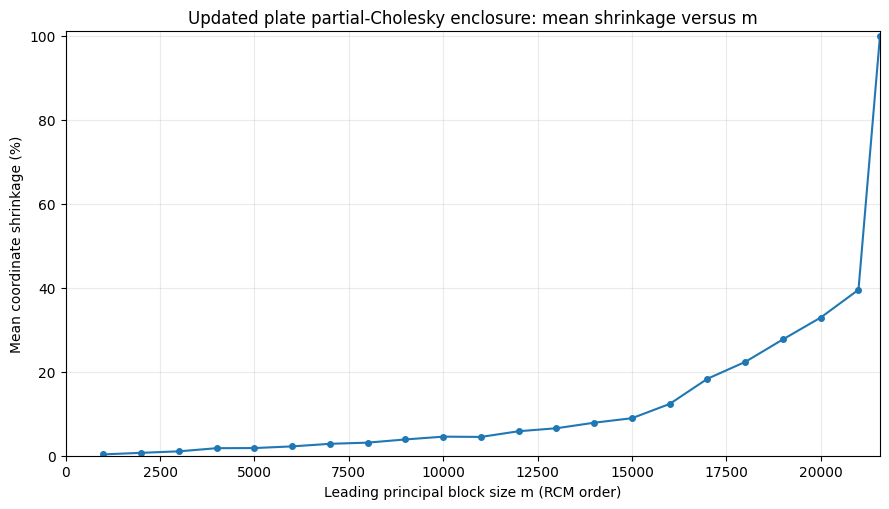

saved system_updated_plate_solver_v7_results/mean_shrinkage_vs_m.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(m_values, mean_shrinkage_pct, color="tab:blue", marker="o", markersize=4)
ax.set(
    xlabel="Leading principal block size m (RCM order)",
    ylabel="Mean coordinate shrinkage (%)",
    title="Updated plate partial-Cholesky enclosure: mean shrinkage versus m",
    xlim=(0, n),
    ylim=(0, 101),
)
ax.grid(alpha=0.25)
fig.tight_layout()
mean_plot_path = results_dir / "mean_shrinkage_vs_m.png"
fig.savefig(mean_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {mean_plot_path}")


## Histogram animation

All frames use the same 40 bins on `[0%, 100%]`, a fixed x-axis, and a common y-axis determined across the complete animation.

saved system_updated_plate_solver_v7_results/coordinate_shrinkage_histogram.gif


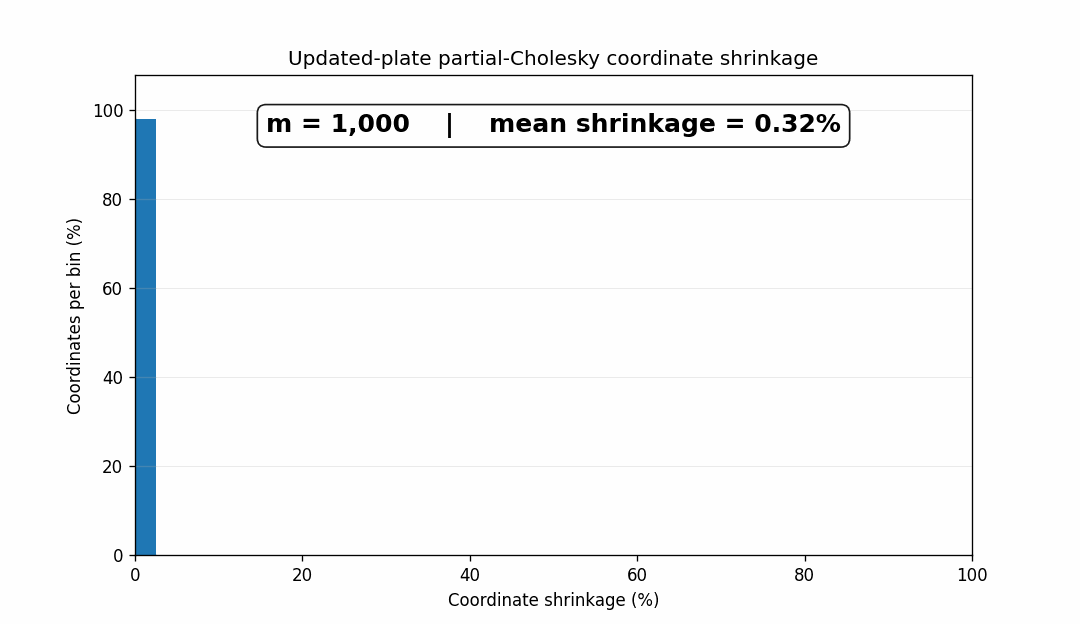

In [6]:
histogram_edges = np.linspace(0.0, 100.0, 41)
histogram_pct = np.vstack([
    100.0 * np.histogram(values, bins=histogram_edges)[0] / n
    for values in coordinate_shrinkage_pct
])
common_ymax = max(1.0, 1.08 * histogram_pct.max())

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(
    histogram_edges[:-1], histogram_pct[0], width=np.diff(histogram_edges),
    align="edge", color="tab:blue", edgecolor="white", linewidth=0.5,
)
frame_label = ax.text(
    0.5, 0.92, "", transform=ax.transAxes, ha="center", va="top",
    fontsize=15, fontweight="bold",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.9},
)
ax.set(
    xlim=(0.0, 100.0), ylim=(0.0, common_ymax),
    xlabel="Coordinate shrinkage (%)",
    ylabel="Coordinates per bin (%)",
    title="Updated-plate partial-Cholesky coordinate shrinkage",
)
ax.grid(axis="y", alpha=0.25)

def update_histogram(frame):
    for bar, height in zip(bars, histogram_pct[frame]):
        bar.set_height(height)
    frame_label.set_text(
        f"m = {m_values[frame]:,}    |    mean shrinkage = {mean_shrinkage_pct[frame]:.2f}%"
    )
    return (*bars, frame_label)

animation = FuncAnimation(
    fig, update_histogram, frames=m_values.size, interval=350, blit=False, repeat=True
)
animation_path = results_dir / "coordinate_shrinkage_histogram.gif"
animation.save(animation_path, writer=PillowWriter(fps=3), dpi=120)
plt.close(fig)
print(f"saved {animation_path}")
display(Image(filename=str(animation_path)))
